In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv(r"C:\Users\heman\Downloads\train (1).csv",usecols=["GarageQual","FireplaceQu","SalePrice"])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FireplaceQu  770 non-null    object
 1   GarageQual   1379 non-null   object
 2   SalePrice    1460 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [4]:
df.isnull().sum().mean

<bound method Series.mean of FireplaceQu    690
GarageQual      81
SalePrice        0
dtype: int64>

In [5]:
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


Text(0, 0.5, 'no. of houses')

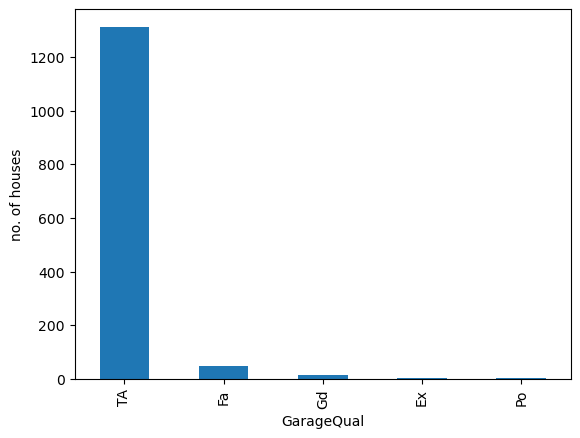

In [6]:
df["GarageQual"].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel("GarageQual")
plt.ylabel("no. of houses")

In [7]:
x=df.drop(columns=["SalePrice"])
y=df["SalePrice"]

In [14]:
x["FireplaceQu_mode"]=x["FireplaceQu"].fillna(x["FireplaceQu"].mode())

In [15]:
x["GarageQual_mode"]=x["GarageQual"].fillna(x["GarageQual"].mode())

In [16]:
x

,FireplaceQu,GarageQual,FireplaceQu_mode,GarageQual_mode
0,NaN,TA,Gd,TA
1,TA,TA,TA,TA
2,TA,TA,TA,TA
3,Gd,TA,Gd,TA
4,TA,TA,TA,TA
...,...,...,...,...
1455,TA,TA,TA,TA
1456,TA,TA,TA,TA
1457,Gd,TA,Gd,TA
1458,NaN,TA,NaN,TA


<AxesSubplot:ylabel='Density'>

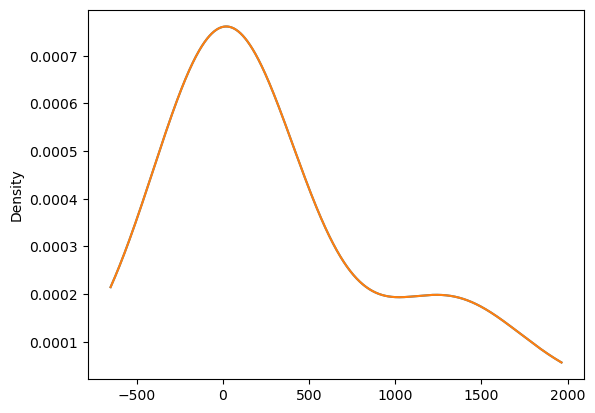

In [27]:
fig=plt.figure()
ax=fig.add_subplot(111)
df["GarageQual"].value_counts().plot(kind="kde",ax=ax)
x["GarageQual_mode"].value_counts().plot(kind="kde",ax=ax)

<AxesSubplot:ylabel='Density'>

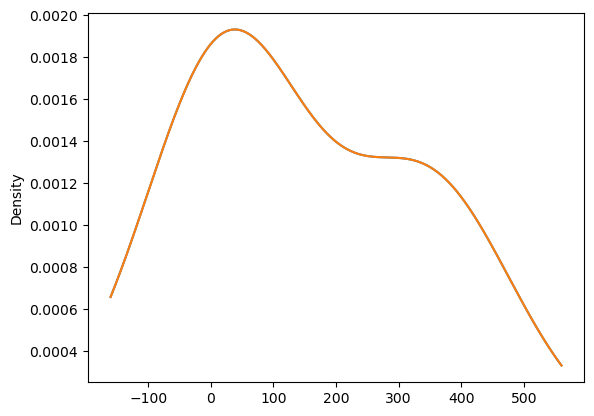

In [28]:
fig=plt.figure()
ax=fig.add_subplot(111)
df["FireplaceQu"].value_counts().plot(kind="kde",ax=ax)
x["FireplaceQu"].value_counts().plot(kind="kde",ax=ax)

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["SalePrice"]),df["SalePrice"],test_size=0.2,random_state=42)

In [30]:
from sklearn.impute import SimpleImputer

In [34]:
impt=SimpleImputer(strategy='most_frequent')

In [35]:
x_train=impt.fit_transform(x_train)
x_test=impt.transform(x_test)

In [36]:
x_train

array([['Gd', 'TA'],
       ['TA', 'TA'],
       ['Gd', 'TA'],
       ...,
       ['Gd', 'TA'],
       ['Gd', 'TA'],
       ['TA', 'TA']], dtype=object)

In [37]:
impt.statistics_

array(['Gd', 'TA'], dtype=object)

In [14]:
impt1=SimpleImputer(strategy="constant",fill_value="Missing")

In [16]:
from sklearn.compose import ColumnTransformer

In [17]:
trf=ColumnTransformer(transformers=[
    ("trf1",impt1,["FireplaceQu","GarageQual"])   
],remainder="passthrough")

In [18]:
trf.fit(x_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('trf1',
                                 SimpleImputer(fill_value='Missing',
                                               strategy='constant'),
                                 ['FireplaceQu', 'GarageQual'])])

In [19]:
x_train=trf.transform(x_train)
x_test=trf.transform(x_test)

In [33]:
trf.transformers[0]

('trf1',
 SimpleImputer(fill_value='Missing', strategy='constant'),
 ['FireplaceQu', 'GarageQual'])